In [1]:
import os
files = os.listdir()
print(files)

['.config', 'Museum_Test.zip', 'Museum_Training.zip', 'sample_data']


In [3]:
import zipfile
zip_file_path = 'Museum_Training.zip'
extraction_path = 'Museum_Training1'

zip_file_path2 = 'Museum_Test.zip'
extraction_path2 = 'Museum_Test1'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

with zipfile.ZipFile(zip_file_path2, 'r') as zip_ref:
    zip_ref.extractall(extraction_path2)


In [4]:
import os
files = os.listdir()
print(files)

['.config', 'Museum_Training1', 'Museum_Test.zip', 'Museum_Test1', 'Museum_Training.zip', 'sample_data']


In [5]:
def list_subdirectories(directory):
    subdirectories = [f for f in os.listdir(directory) if os.path.isdir(os.path.join(directory, f))]
    return subdirectories

root_directory = 'Museum_Training1'
subdirs = list_subdirectories(root_directory)
print(subdirs)

toot_directory2 = 'Museum_Test1'
subdirs2 = list_subdirectories(toot_directory2)
print(subdirs2)

['Training']
['Museum_Validation']


In [6]:
# Data Preparation
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import os
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

class MuseumDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.classes = ['museum-indoor', 'museum-outdoor']
        self.image_paths = []
        self.labels = []

        for class_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_dir, img_name))
                    self.labels.append(class_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_train_dataset = MuseumDataset(
    root_dir='Museum_Training1/Training',
    transform=train_transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Loading original test set
test_dataset = MuseumDataset(
    root_dir='Museum_Test1/Museum_Validation',
    transform=test_transform
)

# Verifying the splits
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 8000
Validation samples: 2000
Test samples: 200


In [7]:
# Testing for GPU
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [8]:
# CNN architecture

class MuseumCNN(nn.Module):
    def __init__(self, num_conv_layers=3, dropout_rate=0.5):
        super().__init__()
        layers = []
        in_channels = 3

        # Dynamic convolutional layers
        for i in range(num_conv_layers):
            out_channels = 32 * (2**i)
            layers += [
                nn.Conv2d(in_channels, out_channels, 3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2)
            ]
            in_channels = out_channels

        self.features = nn.Sequential(*layers)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Linear(in_channels * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [10]:
# Hyperparameter Tuning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def tune_hyperparameters():
    param_grid = {
        'num_conv_layers': [2, 3, 4],
        'dropout_rate': [0.2, 0.3, 0.5],
        'lr': [0.1,0.001, 0.0001],
        'batch_size': [32, 64, 128]
    }

    results = []  # Store all results
    best_acc = 0
    best_params = {}

    for n_layers in param_grid['num_conv_layers']:
        for dropout in param_grid['dropout_rate']:
            for lr in param_grid['lr']:
                for bs in param_grid['batch_size']:
                    print(f"\nTesting: layers={n_layers}, dropout={dropout}, lr={lr}, bs={bs}")

                    model = MuseumCNN(n_layers, dropout).to(device)
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                    criterion = nn.CrossEntropyLoss()
                    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

                    # Track all epoch metrics
                    train_losses, train_accs, val_accs = [], [], []

                    for epoch in range(2):  # Train for 5 epochs
                        model.train()
                        train_loss, train_correct, total = 0.0, 0, 0
                        for images, labels in train_loader:
                            images, labels = images.to(device), labels.to(device)
                            optimizer.zero_grad()
                            outputs = model(images)
                            loss = criterion(outputs, labels)
                            loss.backward()
                            optimizer.step()
                            train_loss += loss.item()
                            _, predicted = torch.max(outputs.data, 1)
                            total += labels.size(0)
                            train_correct += (predicted == labels).sum().item()

                        model.eval()
                        val_correct, val_total = 0, 0
                        with torch.no_grad():
                            for images, labels in val_loader:
                                images, labels = images.to(device), labels.to(device)
                                outputs = model(images)
                                _, predicted = torch.max(outputs.data, 1)
                                val_total += labels.size(0)
                                val_correct += (predicted == labels).sum().item()

                        train_acc = train_correct / total
                        val_acc = val_correct / val_total
                        train_loss_avg = train_loss / len(train_loader)

                        train_losses.append(train_loss_avg)
                        train_accs.append(train_acc)
                        val_accs.append(val_acc)  # Store each epoch's val_acc

                        print(f"Epoch {epoch+1}: Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

                    current_result = {
                        'num_conv_layers': n_layers,
                        'dropout_rate': dropout,
                        'lr': lr,
                        'batch_size': bs,
                    }

                    # Update best_params if current model is better
                    if max(val_accs) > best_acc:
                        best_acc = max(val_accs)
                        best_params = current_result
                        print(f"New best val_acc: {best_acc:.4f}")

                    # Store results for this config
                    current_result_final = {
                        'num_conv_layers': n_layers,
                        'dropout_rate': dropout,
                        'lr': lr,
                        'batch_size': bs,
                        'train_losses': train_losses,
                        'train_accs': train_accs,
                        'val_accs': val_accs,
                        'best_acc': best_acc
                    }

                    results.append(current_result_final)
    return best_params, results,best_acc

best_params, all_results,best_acc = tune_hyperparameters()
print(best_params)
print(f"New best val_acc: {best_acc:.4f}")


Testing: layers=2, dropout=0.2, lr=0.1, bs=32
Epoch 1: Train Loss: 8.6151 | Train Acc: 0.8190 | Val Acc: 0.8695
Epoch 2: Train Loss: 0.3412 | Train Acc: 0.8732 | Val Acc: 0.8790
New best val_acc: 0.8790

Testing: layers=2, dropout=0.2, lr=0.1, bs=64
Epoch 1: Train Loss: 15.6082 | Train Acc: 0.7760 | Val Acc: 0.8620
Epoch 2: Train Loss: 0.3567 | Train Acc: 0.8656 | Val Acc: 0.8765

Testing: layers=2, dropout=0.2, lr=0.1, bs=128
Epoch 1: Train Loss: 29.7022 | Train Acc: 0.6408 | Val Acc: 0.8455
Epoch 2: Train Loss: 0.3734 | Train Acc: 0.8589 | Val Acc: 0.8615

Testing: layers=2, dropout=0.2, lr=0.001, bs=32
Epoch 1: Train Loss: 0.3399 | Train Acc: 0.8612 | Val Acc: 0.8815
Epoch 2: Train Loss: 0.2865 | Train Acc: 0.8894 | Val Acc: 0.8890
New best val_acc: 0.8890

Testing: layers=2, dropout=0.2, lr=0.001, bs=64
Epoch 1: Train Loss: 0.3439 | Train Acc: 0.8540 | Val Acc: 0.8800
Epoch 2: Train Loss: 0.2814 | Train Acc: 0.8909 | Val Acc: 0.8445

Testing: layers=2, dropout=0.2, lr=0.001, bs=12

In [12]:
print(best_params)

{'num_conv_layers': 4, 'dropout_rate': 0.2, 'lr': 0.0001, 'batch_size': 32}


In [13]:
with open('all_results.txt', 'w') as f:
    f.write(str(all_results))

with open('best_params.txt', 'w') as f:
    f.write(str(best_params))

In [15]:
import pandas as pd

df = pd.DataFrame(all_results)

df.head()

,num_conv_layers,dropout_rate,lr,batch_size,train_losses,train_accs,val_accs,best_acc
0,2,0.2,0.100,32,"[8.615085924178361, 0.3412375111579895]","[0.819, 0.87325]","[0.8695, 0.879]",0.879
1,2,0.2,0.100,64,"[15.60818230676651, 0.3567075674533844]","[0.776, 0.865625]","[0.862, 0.8765]",0.879
2,2,0.2,0.100,128,"[29.70220432395027, 0.3733693363647612]","[0.64075, 0.858875]","[0.8455, 0.8615]",0.879
3,2,0.2,0.001,32,"[0.339924043148756, 0.2864999969005585]","[0.86125, 0.889375]","[0.8815, 0.889]",0.889
4,2,0.2,0.001,64,"[0.343913190305233, 0.2813844412565231]","[0.854, 0.890875]","[0.88, 0.8445]",0.889


In [16]:
!pip install seaborn --quiet
import matplotlib.pyplot as plt
import seaborn as sns


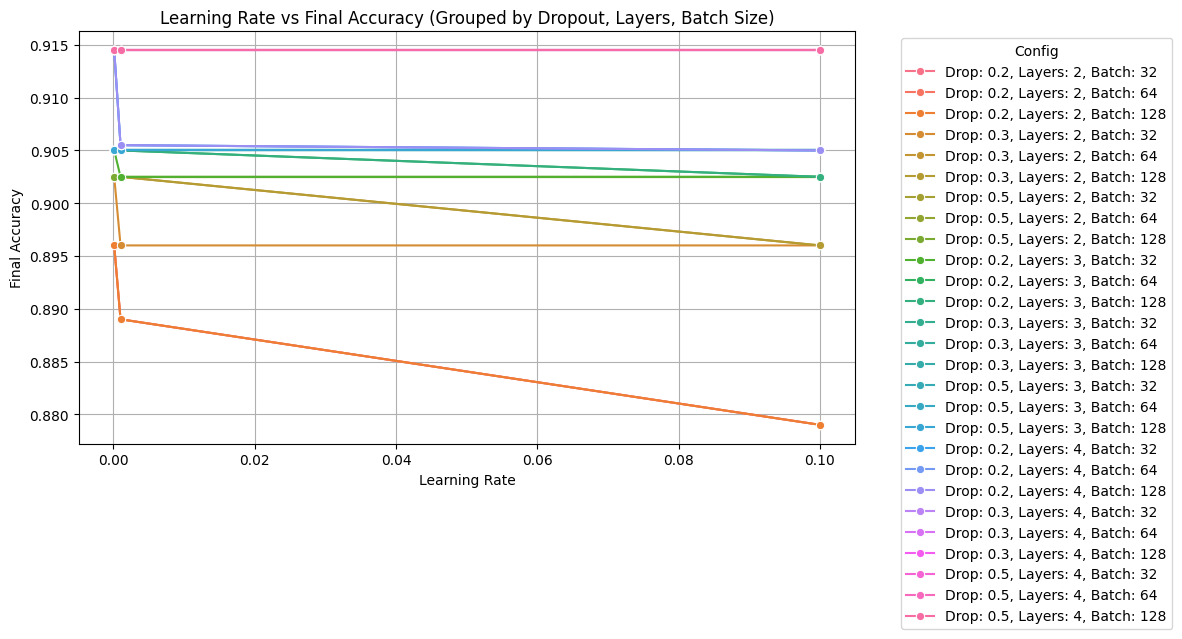

In [17]:
df['config'] = df.apply(
    lambda row: f"Drop: {row.dropout_rate}, Layers: {row.num_conv_layers}, Batch: {row.batch_size}", axis=1
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='lr', y='best_acc', hue='config', marker='o')

plt.title("Learning Rate vs Final Accuracy (Grouped by Dropout, Layers, Batch Size)")
plt.xlabel("Learning Rate")
plt.ylabel("Final Accuracy")
plt.grid(True)
plt.legend(title="Config", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

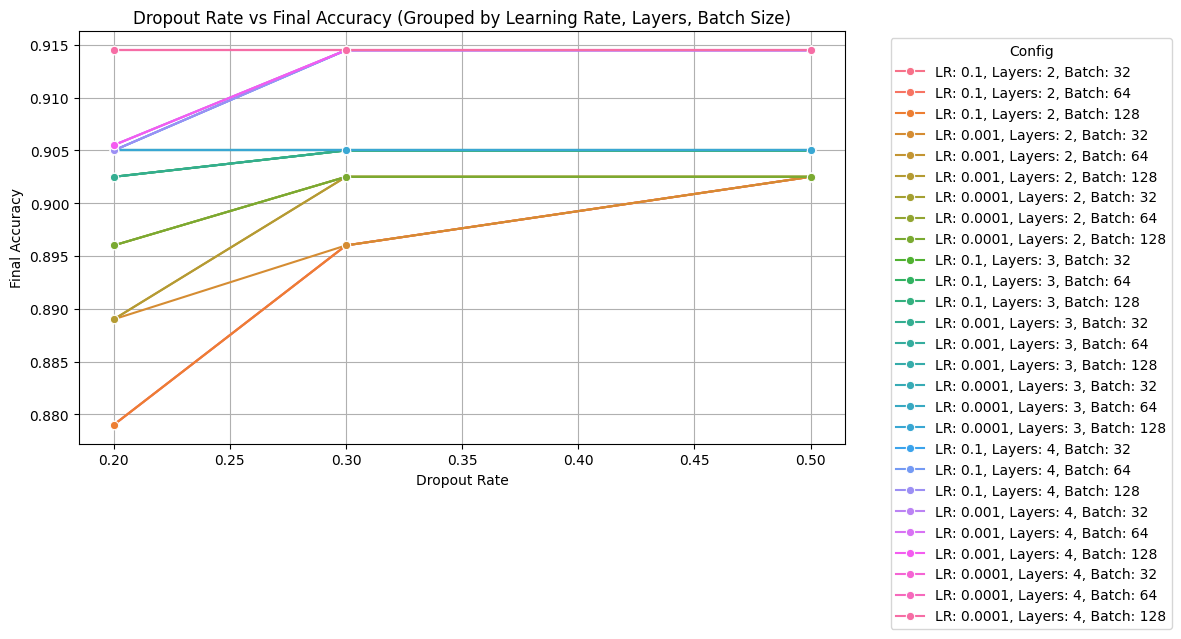

In [18]:
df['config'] = df.apply(
    lambda row: f"LR: {row.lr}, Layers: {row.num_conv_layers}, Batch: {row.batch_size}", axis=1
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='dropout_rate', y='best_acc', hue='config', marker='o')

plt.title("Dropout Rate vs Final Accuracy (Grouped by Learning Rate, Layers, Batch Size)")
plt.xlabel("Dropout Rate")
plt.ylabel("Final Accuracy")
plt.grid(True)
plt.legend(title="Config", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

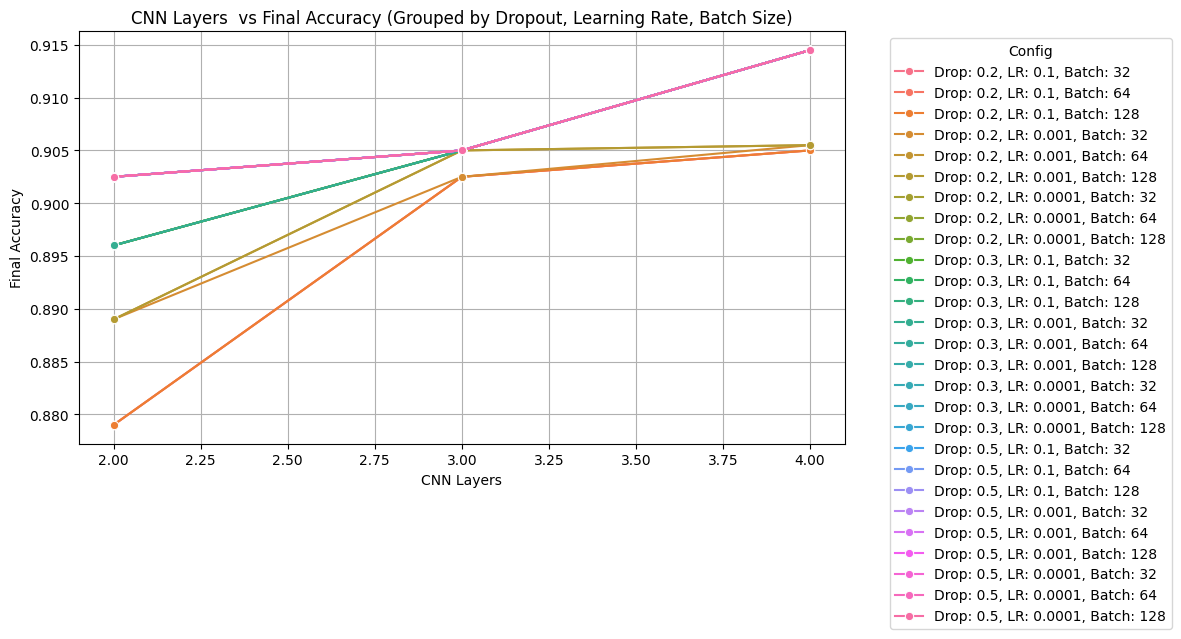

In [19]:
df['config'] = df.apply(
    lambda row: f"Drop: {row.dropout_rate}, LR: {row.lr}, Batch: {row.batch_size}", axis=1
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='num_conv_layers', y='best_acc', hue='config', marker='o')

plt.title("CNN Layers  vs Final Accuracy (Grouped by Dropout, Learning Rate, Batch Size)")
plt.xlabel("CNN Layers")
plt.ylabel("Final Accuracy")
plt.grid(True)
plt.legend(title="Config", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

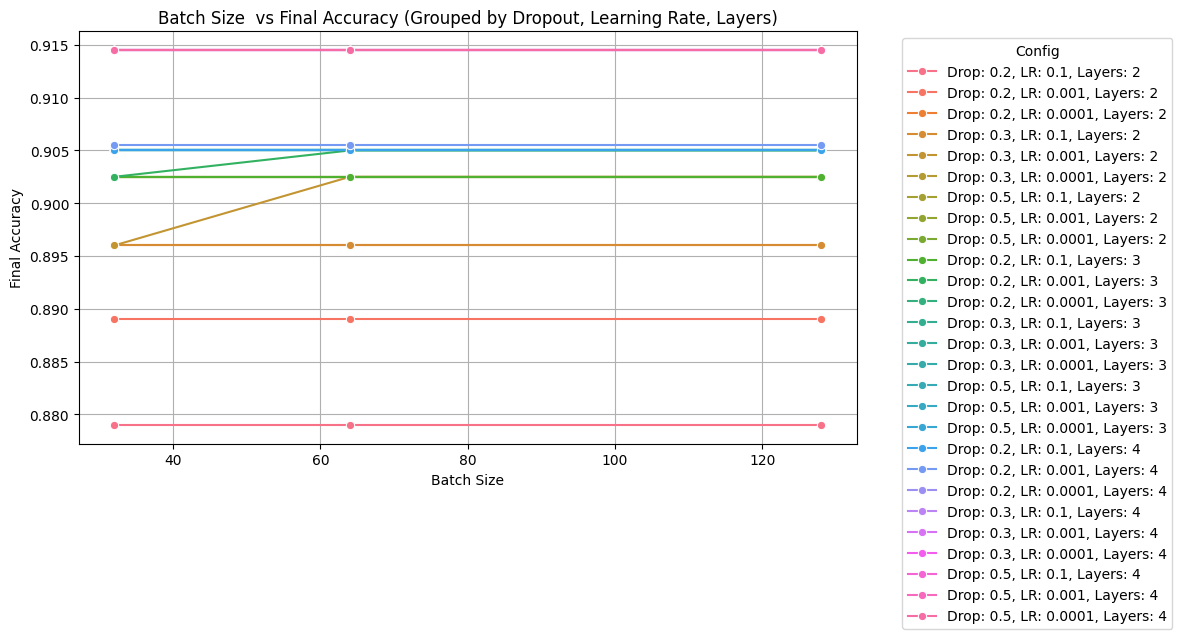

In [20]:
df['config'] = df.apply(
    lambda row: f"Drop: {row.dropout_rate}, LR: {row.lr}, Layers: {row.num_conv_layers}", axis=1
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='batch_size', y='best_acc', hue='config', marker='o')

plt.title("Batch Size  vs Final Accuracy (Grouped by Dropout, Learning Rate, Layers)")
plt.xlabel("Batch Size")
plt.ylabel("Final Accuracy")
plt.grid(True)
plt.legend(title="Config", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
# Initialize with best params
model = MuseumCNN(
    num_conv_layers=best_params['num_conv_layers'],
    dropout_rate=best_params['dropout_rate']
).to(device)

optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True,pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False,pin_memory=True)

# Training loop
def train_model(model, train_loader, val_loader, optimizer, epochs=15):
    criterion = nn.CrossEntropyLoss()
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # Validation
        val_loss, val_acc = validate(model, val_loader, criterion)

        print(f"Results:")
        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}\n")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'hyperparameters': best_params,
                'val_accuracy': val_acc,
                'epoch': epoch
            }, 'best_cnn_model_full.pth')
            print(f"New best model saved (val_acc: {val_acc:.4f})\n")

    return model

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss/len(loader), correct/total

# Start training
trained_model = train_model(model, train_loader, val_loader, optimizer)

Epoch 1: 100%|██████████| 250/250 [00:23<00:00, 10.74it/s]


Results:
Train Loss: 0.3052 | Acc: 0.8759
Val Loss: 0.3132 | Acc: 0.8795

New best model saved (val_acc: 0.8795)



Epoch 2: 100%|██████████| 250/250 [00:25<00:00,  9.78it/s]


Results:
Train Loss: 0.2437 | Acc: 0.9079
Val Loss: 0.2406 | Acc: 0.9110

New best model saved (val_acc: 0.9110)



Epoch 3: 100%|██████████| 250/250 [00:23<00:00, 10.72it/s]


...

Results:
Train Loss: 0.1287 | Acc: 0.9544
Val Loss: 0.2460 | Acc: 0.9220



Epoch 14: 100%|██████████| 250/250 [00:23<00:00, 10.72it/s]


Results:
Train Loss: 0.1268 | Acc: 0.9535
Val Loss: 0.1637 | Acc: 0.9420

New best model saved (val_acc: 0.9420)



Epoch 15: 100%|██████████| 250/250 [00:23<00:00, 10.84it/s]


Results:
Train Loss: 0.1218 | Acc: 0.9540
Val Loss: 0.1848 | Acc: 0.9345



Accuracy: 0.9400
Precision: 0.9402
Recall: 0.9400
F1-score: 0.9400
              precision  recall  f1-score  support
Indoor         0.948980    0.93  0.939394   100.00
Outdoor        0.931373    0.95  0.940594   100.00
accuracy       0.940000    0.94  0.940000     0.94
macro avg      0.940176    0.94  0.939994   200.00
weighted avg   0.940176    0.94  0.939994   200.00
[[93  7]
 [ 5 95]]


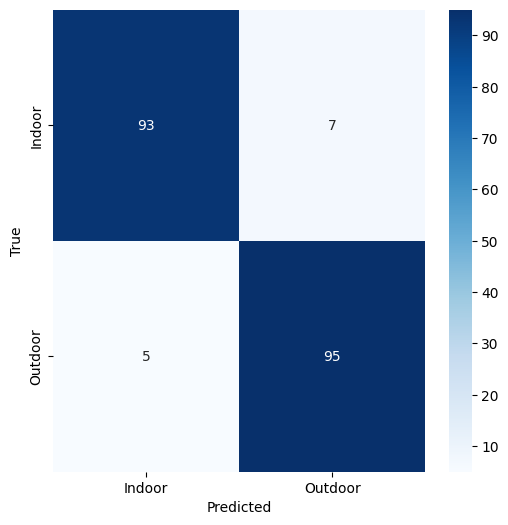


Test Accuracy: 0.9400


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score,roc_curve, auc, precision_recall_curve,average_precision_score
import pandas as pd
import numpy as np

# Load best model
checkpoint = torch.load('best_cnn_model_full.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
best_hyper_params = checkpoint['hyperparameters']
best_val_acc = checkpoint['val_accuracy']
test_loader = DataLoader(test_dataset, batch_size=best_hyper_params['batch_size'], shuffle=False)

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        _, preds = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
class_report=classification_report(all_labels, all_preds, target_names=['Indoor', 'Outdoor'],output_dict=True)
report_df = pd.DataFrame(class_report).transpose()
print(report_df.to_string(index=True))
results = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
}
df_metrics = pd.DataFrame(results)
conf_matrix = confusion_matrix(all_labels, all_preds)
print(str(conf_matrix))
with open("cnn_model.txt", "w") as file:
    file.write("\nMetrics:\n")
    df_metrics.to_string(file, index=False)
    file.write("\nClassification Report:\n")
    file.write("\n")
    file.write(report_df.to_string(index=True))
    file.write("\nConfusion Matrix:\n")
    file.write(str(conf_matrix) + "\n")
    file.write("\nBest Hyperparameters:\n")
    file.write(str(best_params) + "\n")

# Confusion Matrix
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(all_labels, all_preds),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Indoor', 'Outdoor'],
            yticklabels=['Indoor', 'Outdoor'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(f"\nTest Accuracy: {accuracy:.4f}")

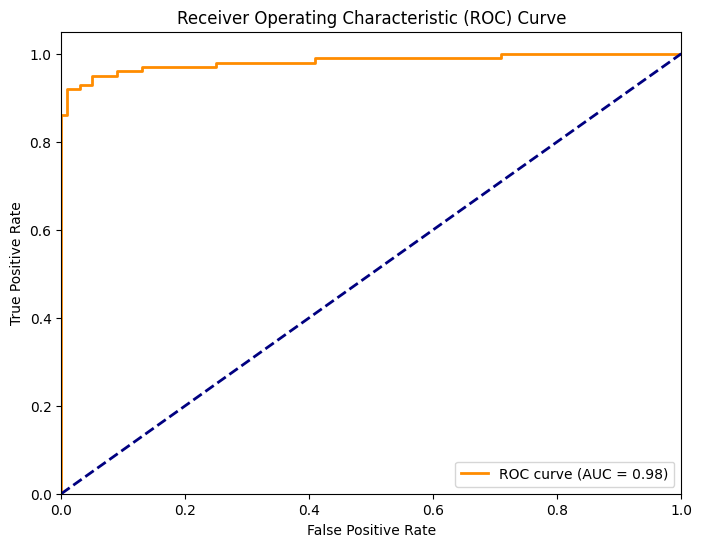

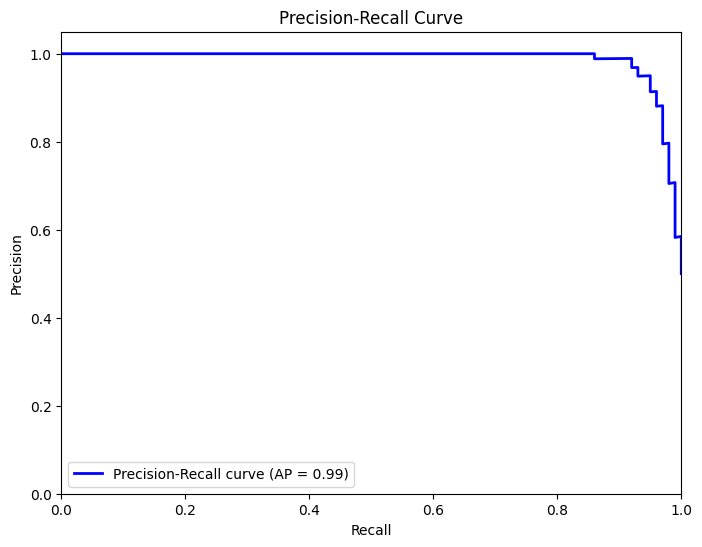

In [23]:
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
positive_class_probs = all_probs[:, 1]
fpr, tpr, thresholds = roc_curve(all_labels, positive_class_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')
plt.show()

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(all_labels, positive_class_probs)
average_precision = average_precision_score(all_labels, positive_class_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2,
         label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.savefig('precision_recall_curve.png')
plt.show()

In [28]:
def predict_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img = test_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)
        return 'Indoor' if pred.item() == 0 else 'Outdoor'

print(predict_image('indoor1.jpeg'))
print(predict_image('outdoor1.jpeg'))

Indoor
Outdoor


In [29]:
import re

def extract_xgb_metrics(file_path):
    with open(file_path, 'r') as file:
        text = file.read()
    accuracy_match = re.search(r'Accuracy:\s*([0-9.]+)', text)
    precision_match = re.search(r'Precision:\s*([0-9.]+)', text)
    recall_match = re.search(r'Recall:\s*([0-9.]+)', text)
    f1_score_match = re.search(r'F1 Score:\s*([0-9.]+)', text)
    metrics = {
        'Accuracy': accuracy_match.group(1) if accuracy_match else None,
        'Precision': precision_match.group(1) if precision_match else None,
        'Recall': recall_match.group(1) if recall_match else None,
        'F1-Score': f1_score_match.group(1) if f1_score_match else None
    }
    return metrics

def extract_metrics_from_file(file_path):
    with open(file_path, 'r') as file:
        text = file.read()

    accuracy_match = re.search(r'Accuracy\s+([0-9.]+)', text)
    precision_match = re.search(r'Precision\s+([0-9.]+)', text)
    recall_match = re.search(r'Recall\s+([0-9.]+)', text)
    f1_score_match = re.search(r'F1-Score\s+([0-9.]+)', text)
    metrics = {
        'Accuracy': accuracy_match.group(1) if accuracy_match else None,
        'Precision': precision_match.group(1) if precision_match else None,
        'Recall': recall_match.group(1) if recall_match else None,
        'F1-Score': f1_score_match.group(1) if f1_score_match else None
    }
    return metrics

file_path1 = 'adaboost.txt'
metrics1 = extract_metrics_from_file(file_path1)
file_path2 = 'decision_tree_results.txt'
metrics2 = extract_metrics_from_file(file_path2)
file_path3 = 'random_forest_results.txt'
metrics3 = extract_metrics_from_file(file_path3)
file_path4 = 'semisupervised_decision_tree.txt'
metrics4 = extract_metrics_from_file(file_path4)
file_path5 = 'cnn_model.txt'
metrics5 = extract_metrics_from_file(file_path5)

# Print the extracted metrics
print("Metrics from adaboost_results.txt:")
for key, value in metrics1.items():
    print(f'{key}: {value}')
print("\nMetrics from decision_tree_results.txt:")
for key, value in metrics2.items():
    print(f'{key}: {value}')
print("\nMetrics from random_forest_results.txt:")
for key, value in metrics3.items():
    print(f'{key}: {value}')
print("\nMetrics from semisupervised_decision_tree.txt:")
for key, value in metrics4.items():
    print(f'{key}: {value}')
print("\nMetrics from cnn_model.txt:")
for key, value in metrics5.items():
    print(f'{key}: {value}')



Metrics from adaboost_results.txt:
Accuracy: 0.853500
Precision: 0.867846
Recall: 0.834000
F1-Score: 0.850586

Metrics from decision_tree_results.txt:
Accuracy: 0.815000
Precision: 0.846154
Recall: 0.770000
F1-Score: 0.806283

Metrics from random_forest_results.txt:
Accuracy: 0.875000
Precision: 0.894737
Recall: 0.850000
F1-Score: 0.871795

Metrics from semisupervised_decision_tree.txt:
Accuracy: 0.790000
Precision: 0.802083
Recall: 0.770000
F1-Score: 0.785714

Metrics from cnn_model.txt:
Accuracy: 0.940000
Precision: 0.940176
Recall: 0.940000
F1-Score: 0.939994


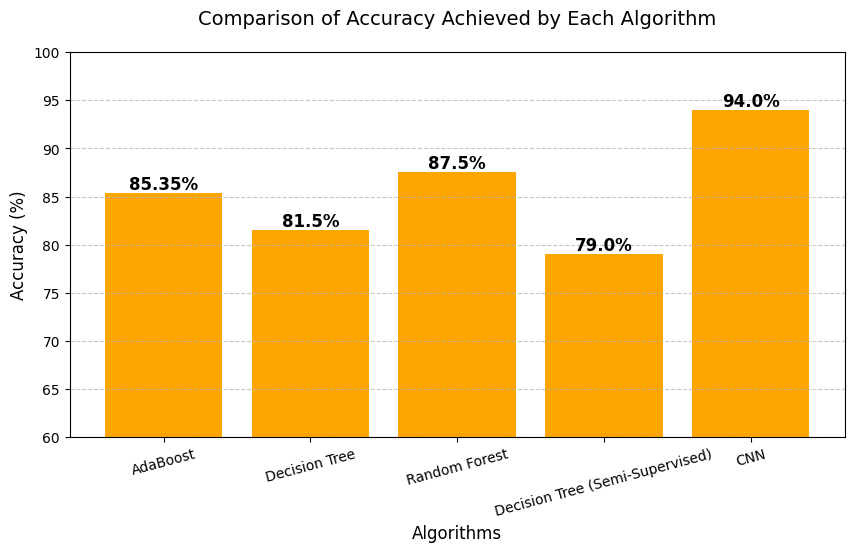

In [30]:
import matplotlib.pyplot as plt

models = ["AdaBoost", "Decision Tree", "Random Forest", "Decision Tree (Semi-Supervised)", "CNN"]
metrics = [metrics1, metrics2, metrics3, metrics4, metrics5]
accuracy_values = [round(float(m["Accuracy"]) * 100, 3) for m in metrics]
colors = 'orange'
plt.figure(figsize=(10, 5))
bars = plt.bar(models, accuracy_values, color=colors)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height()}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Comparison of Accuracy Achieved by Each Algorithm", fontsize=14,pad=20)
plt.ylim(60, 100)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


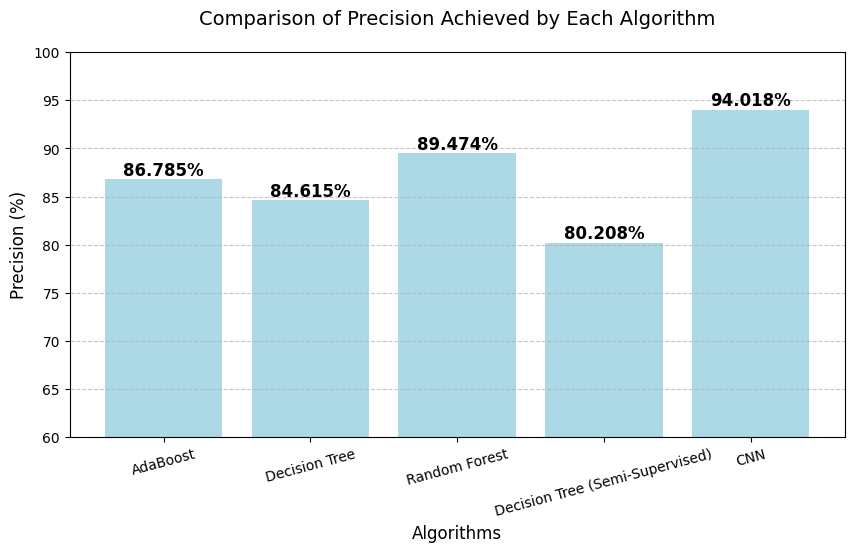

In [31]:
import matplotlib.pyplot as plt

models = ["AdaBoost", "Decision Tree", "Random Forest", "Decision Tree (Semi-Supervised)", "CNN"]
metrics = [metrics1, metrics2, metrics3, metrics4, metrics5]
precision_values = [round(float(m["Precision"]) * 100, 3) for m in metrics]
colors = 'lightblue'
plt.figure(figsize=(10, 5))
bars = plt.bar(models, precision_values, color=colors)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height()}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Precision (%)", fontsize=12)
plt.title("Comparison of Precision Achieved by Each Algorithm", fontsize=14,pad=20)
plt.ylim(60, 100)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


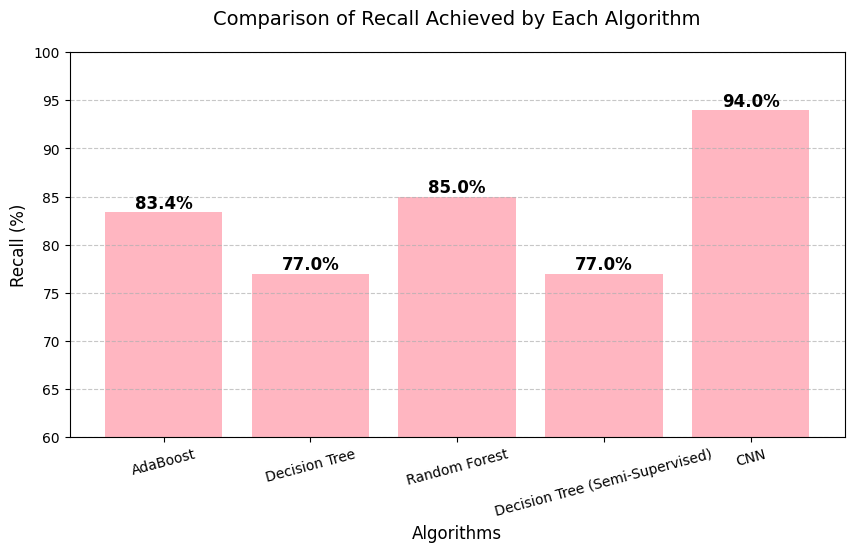

In [32]:
import matplotlib.pyplot as plt

models = ["AdaBoost", "Decision Tree", "Random Forest", "Decision Tree (Semi-Supervised)","CNN"]
metrics = [metrics1, metrics2, metrics3, metrics4, metrics5]
recall_values = [round(float(m["Recall"]) * 100, 3) for m in metrics]
colors = 'lightpink'
plt.figure(figsize=(10, 5))
bars = plt.bar(models, recall_values, color=colors)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height()}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Recall (%)", fontsize=12)
plt.title("Comparison of Recall Achieved by Each Algorithm", fontsize=14,pad=20)
plt.ylim(60, 100)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


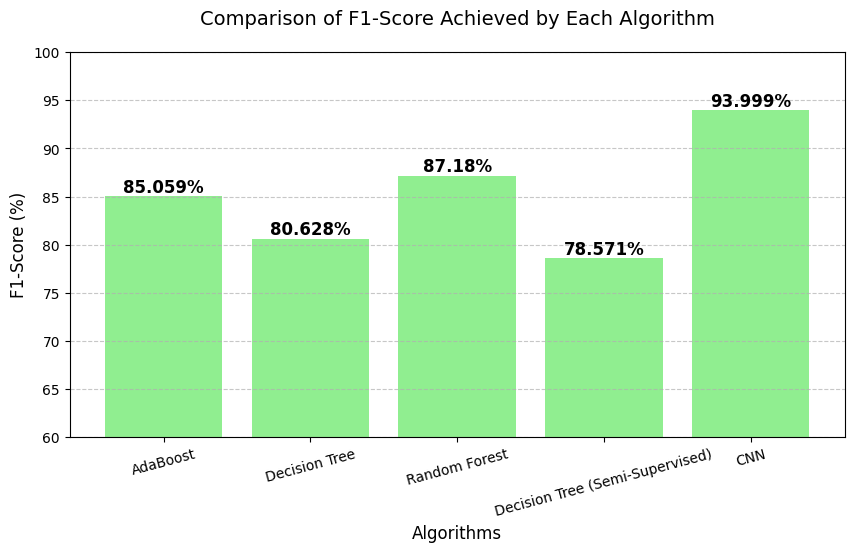

In [33]:
import matplotlib.pyplot as plt

models = ["AdaBoost", "Decision Tree", "Random Forest", "Decision Tree (Semi-Supervised)","CNN"]
metrics = [metrics1, metrics2, metrics3, metrics4, metrics5]
f1_score_values = [round(float(m["F1-Score"]) * 100, 3) for m in metrics]
colors = 'lightgreen'
plt.figure(figsize=(10, 5))
bars = plt.bar(models, f1_score_values, color=colors)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height()}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("F1-Score (%)", fontsize=12)
plt.title("Comparison of F1-Score Achieved by Each Algorithm", fontsize=14,pad=20)
plt.ylim(60, 100)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
